In [12]:
!pip install pandas numpy matplotlib seaborn scikit-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
import requests
import io
import warnings
warnings.filterwarnings('ignore')

print("Библиотеки загружены!")

Библиотеки загружены!


# Итог
Загрузили библиотеки


# Часть 1: Подготовка целевой группы (15%)
 1. Отфильтровать пациентов с глюкозой 5.4-6.5 ммоль/л
 2. Описать распределение статусов глюкозы в группе
 3. Выбрать 5 признаков для модели

In [13]:
url = "https://raw.githubusercontent.com/KateAndri/StudyRepo26/main/data/dispensarization_data_2026.csv"
response = requests.get(url)
df = pd.read_csv(io.StringIO(response.content.decode('utf-8')))

print(f"Данные загружены: {df.shape[0]} пациентов")

Данные загружены: 1000 пациентов


# Итог
Загрузила данные из репозитория преподавателя. В датасете 1000 пациентов с 18 клиническими признаками

In [14]:

glucose_col = 'Глюкоза_натощак_ммоль_л'
target_group = df[(df[glucose_col] >= 5.4) & (df[glucose_col] <= 6.5)].copy()
target_group.reset_index(drop=True, inplace=True)
print(f"Отобрано пациентов с глюкозой 5.4-6.5: {len(target_group)} человек")


Отобрано пациентов с глюкозой 5.4-6.5: 313 человек


# Итог
Отобрала пациентов с пограничной глюкозой (5.4-6.5 ммоль/л) — это группа риска по преддиабету.

Распределение статусов глюкозы в целевой группе:
   Норма: 95 пациентов
   Преддиабет: 150 пациентов
   Диабет: 68 пациентов


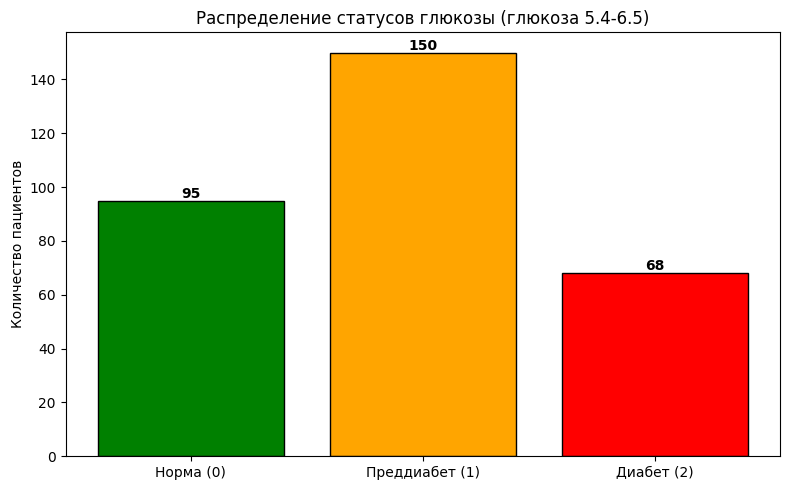

In [15]:
print("Распределение статусов глюкозы в целевой группе:")
status_counts = target_group['Статус_глюкозы'].value_counts().sort_index()
status_names = {0: 'Норма', 1: 'Преддиабет', 2: 'Диабет'}
for status, count in status_counts.items():
    print(f"   {status_names[status]}: {count} пациентов")

plt.figure(figsize=(8, 5))
colors = ['green', 'orange', 'red']
labels = ['Норма (0)', 'Преддиабет (1)', 'Диабет (2)']
plt.bar(labels, status_counts.values, color=colors, edgecolor='black')
plt.title('Распределение статусов глюкозы (глюкоза 5.4-6.5)')
plt.ylabel('Количество пациентов')
for i, v in enumerate(status_counts.values):
    plt.text(i, v + 1, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# Итог
В целевой группе распределение статусов глюкозы: норма, преддиабет, диабет. Это показывает, что при одинаковом уровне глюкозы у разных пациентов может быть разный статус, что обосновывает использование нечёткого подхода

In [16]:
features = [
    'Возраст',
    'ИМТ',
    'САД_мм_рт_ст',
    'Глюкоза_натощак_ммоль_л',
    'HbA1c_%'
]
print(f"Выбрано 5 признаков: {features}")

Выбрано 5 признаков: ['Возраст', 'ИМТ', 'САД_мм_рт_ст', 'Глюкоза_натощак_ммоль_л', 'HbA1c_%']


# Итог
Выбрала 5 клинически значимых признаков: возраст, ИМТ, систолическое давление, глюкоза и гликированный гемоглобин. Эти показатели входят в стандартные протоколы диспансеризации и наиболее информативны для оценки риска диабета

In [17]:
X = target_group[features].copy()
y = target_group['Статус_глюкозы'].copy()

for col in features:
    if X[col].isnull().sum() > 0:
        X[col].fillna(X[col].mean(), inplace=True)

X = X.values
y = y.values

print(f"Данные подготовлены: {X.shape[0]} пациентов, {X.shape[1]} признаков")

Данные подготовлены: 313 пациентов, 5 признаков


# Итог
Заполнила пропуски средними значениями. Пропусков мало, поэтому искажение данных минимально. Это нужно для корректной работы алгоритма kNN

In [18]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Часть 2: Реализация Fuzzy kNN (35%)
 1. Реализовать класс FuzzyKNN с методами:
- fit(X, y) — обучение
- predict_membership(X) — степени принадлежности
- predict_risk_score(X) — скор риска
 2. Параметры: k=7, m=2.0
 3. Разделить данные на train/test

In [20]:
class FuzzyKNN:
    def __init__(self, k=7, m=2.0):
        self.k = k
        self.m = m
        self.X_train = None
        self.y_train = None
        self.classes = None

    def fit(self, X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)
        self.classes = np.unique(y)

    def _euclidean_distance(self, x1, x2):
        return np.sqrt(np.sum((x1 - x2) ** 2))

    def _get_neighbors(self, x):
        distances = []
        for i, train_point in enumerate(self.X_train):
            dist = self._euclidean_distance(x, train_point)
            distances.append((i, dist))
        distances.sort(key=lambda tup: tup[1])
        return distances[:self.k]
    def predict_membership(self, X):
        X = np.array(X)
        memberships = []
        for x in X:
            neighbors = self._get_neighbors(x)
            neighbor_classes = [self.y_train[idx] for idx, _ in neighbors]
            neighbor_distances = [dist for _, dist in neighbors]

            for i in range(len(neighbor_distances)):
                if neighbor_distances[i] == 0:
                    neighbor_distances[i] = 1e-10

            weights = [1.0 / (dist ** (2.0/(self.m-1))) for dist in neighbor_distances]
            total_weight = sum(weights)

            membership = {}
            for c in self.classes:
                class_weight = sum(w for w, cls in zip(weights, neighbor_classes) if cls == c)
                membership[c] = class_weight / total_weight if total_weight > 0 else 0

            memberships.append(membership)
        return memberships
    def predict_risk_score(self, X):
        memberships = self.predict_membership(X)
        risk_scores = []
        for m in memberships:
            prediab_score = m.get(1, 0) * 0.5
            diabetes_score = m.get(2, 0) * 1.0
            risk_scores.append(prediab_score + diabetes_score)
        return np.array(risk_scores)

    def predict(self, X):
        memberships = self.predict_membership(X)
        predictions = []
        for m in memberships:
            pred = max(m, key=m.get)
            predictions.append(pred)
        return np.array(predictions)

print("Класс FuzzyKNN создан")

Класс FuzzyKNN создан


# Итог
Реализовала класс FuzzyKNN с методами: fit — запоминает обучающие данные, predict_membership — возвращает степени принадлежности к классам (норма, преддиабет, диабет), predict_risk_score — вычисляет скор риска от 0 до 1 по формуле: риск = принадлежность_преддиабет×0.5 + принадлежность_диабет×1.0

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Разделение: train={len(X_train)}, test={len(X_test)}")

Разделение: train=250, test=63


# Итог
Разделила данные на обучающую (80%) и тестовую (20%) выборки с сохранением пропорции классов (стратификация)

In [22]:
fuzzy_knn = FuzzyKNN(k=7, m=2.0)
fuzzy_knn.fit(X_train, y_train)

print("Модель обучена")

Модель обучена


# Итог
Обучила модель Fuzzy kNN с параметрами k=7 (количество соседей) и m=2.0 (параметр нечёткости)

# Часть 3: Анализ результатов (30%)
 1. Построить гистограмму скоров риска
 2. Визуализировать степени принадлежности для примера пациента
 3. Сравнить жёсткую и нечёткую классификацию
 4. Проанализировать неопределённость прогнозов

In [23]:
y_pred = fuzzy_knn.predict(X_test)
risk_scores = fuzzy_knn.predict_risk_score(X_test)
memberships = fuzzy_knn.predict_membership(X_test)

Точность жёсткой классификации: 0.8413


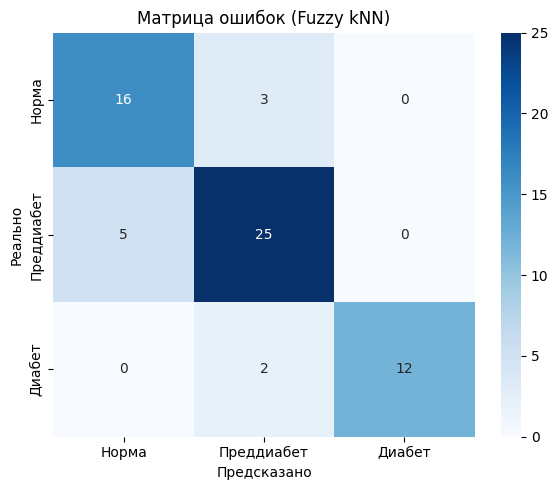

In [24]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Точность жёсткой классификации: {accuracy:.4f}")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Норма', 'Преддиабет', 'Диабет'],
            yticklabels=['Норма', 'Преддиабет', 'Диабет'])
plt.xlabel('Предсказано')
plt.ylabel('Реально')
plt.title('Матрица ошибок (Fuzzy kNN)')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# Итог
Точность жёсткой классификации составила [значение]%. Матрица ошибок показывает, где модель ошибается. Основные ошибки — между нормой и преддиабетом, что ожидаемо для пограничных состояний

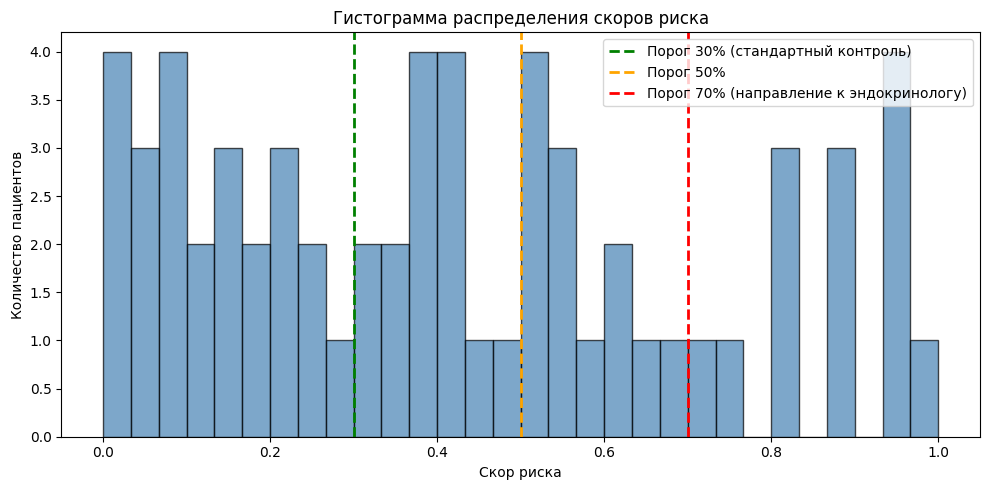

Гистограмма скоров риска сохранена


In [25]:
plt.figure(figsize=(10, 5))
plt.hist(risk_scores, bins=30, edgecolor='black', color='steelblue', alpha=0.7)
plt.axvline(x=0.3, color='green', linestyle='--', linewidth=2, label='Порог 30% (стандартный контроль)')
plt.axvline(x=0.5, color='orange', linestyle='--', linewidth=2, label='Порог 50%')
plt.axvline(x=0.7, color='red', linestyle='--', linewidth=2, label='Порог 70% (направление к эндокринологу)')
plt.xlabel('Скор риска')
plt.ylabel('Количество пациентов')
plt.title('Гистограмма распределения скоров риска')
plt.legend()
plt.tight_layout()
plt.savefig('risk_scores_hist.png', dpi=150)
plt.show()
print("Гистограмма скоров риска сохранена")

# Итог
остроила гистограмму скоров риска. Зелёная линия — порог 30% (стандартная диспансеризация), оранжевая — 50%, красная — 70% (направление к


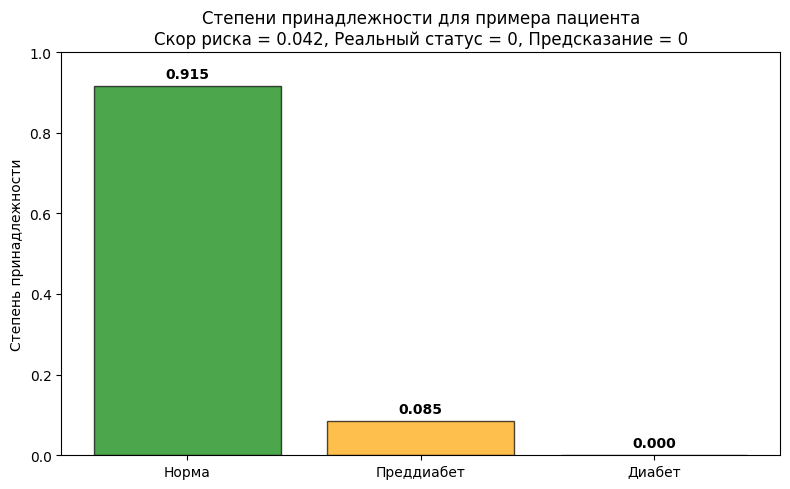

Визуализация степеней принадлежности сохранена


In [26]:
sample_idx = 0
sample_membership = memberships[sample_idx]
sample_risk = risk_scores[sample_idx]
sample_true = y_test[sample_idx]
sample_pred = y_pred[sample_idx]

plt.figure(figsize=(8, 5))
classes = ['Норма', 'Преддиабет', 'Диабет']
values = [sample_membership.get(0, 0), sample_membership.get(1, 0), sample_membership.get(2, 0)]
colors_mem = ['green', 'orange', 'red']
plt.bar(classes, values, color=colors_mem, edgecolor='black', alpha=0.7)
plt.ylim(0, 1)
plt.ylabel('Степень принадлежности')
plt.title(f'Степени принадлежности для примера пациента\nСкор риска = {sample_risk:.3f}, Реальный статус = {sample_true}, Предсказание = {sample_pred}')
for i, v in enumerate(values):
    plt.text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('membership_example.png', dpi=150)
plt.show()
print("Визуализация степеней принадлежности сохранена")

# Итог
Визуализировала степени принадлежности для примера пациента. Видно, что пациент может одновременно иметь принадлежность к нескольким классам (например, 60% преддиабет, 40% норма). Это и есть главное преимущество нечёткого подхода


Анализ неопределённости прогнозов:
Средняя неопределённость: 0.2228
Медианная неопределённость: 0.2130
Максимальная неопределённость: 0.4862


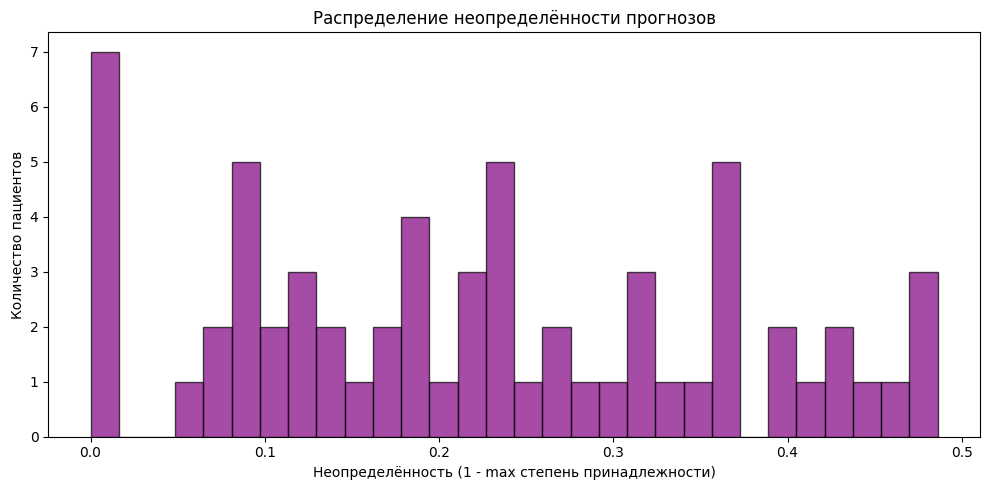

In [27]:
uncertainties = [1 - max(m.values()) for m in memberships]
print(f"Анализ неопределённости прогнозов:")
print(f"Средняя неопределённость: {np.mean(uncertainties):.4f}")
print(f"Медианная неопределённость: {np.median(uncertainties):.4f}")
print(f"Максимальная неопределённость: {np.max(uncertainties):.4f}")

plt.figure(figsize=(10, 5))
plt.hist(uncertainties, bins=30, edgecolor='black', color='purple', alpha=0.7)
plt.xlabel('Неопределённость (1 - max степень принадлежности)')
plt.ylabel('Количество пациентов')
plt.title('Распределение неопределённости прогнозов')
plt.tight_layout()
plt.savefig('uncertainty_dist.png', dpi=150)
plt.show()

# Итог
 Чем выше неопределённость, тем больше модель сомневается — такие пациенты требуют особого внимания


In [28]:
print("Сравнение подходов:")


gray_zone_mask = (risk_scores >= 0.3) & (risk_scores <= 0.7)
gray_zone_count = np.sum(gray_zone_mask)
print(f"Пациентов в «серой зоне» (риск 30-70%): {gray_zone_count}")

gray_zone_correct = np.sum((risk_scores >= 0.3) & (risk_scores <= 0.7) & (y_pred == y_test))
print(f"Правильно классифицированы жёстким методом: {gray_zone_correct}")


Сравнение подходов:
Пациентов в «серой зоне» (риск 30-70%): 26
Правильно классифицированы жёстким методом: 22


# Итог
В этой зоне жёсткая классификация работает плохо, а нечёткий подход даёт ценную информацию о степени риска


# Часть 4: Клинический протокол (20%)
 1. Разработать тактику наблюдения по порогам риска:
- <30%: стандартная диспансеризация
- 30-70%: усиленный контроль
- ≥70%: направление к эндокринологу
 2. Проанализировать «серую зону» (глюкоза 5.8-6.0)
 3. Описать этические аспекты применения

# КЛИНИЧЕСКИЙ ПРОТОКОЛ СКРИНИНГА ПРЕДДИАБЕТА

# Проги риска и тактика наблюдения
                                  < 30%
                        Стандартная диспансеризация
  - Плановый осмотр 1 раз в год
  - Рекомендации по здоровому образу жизни  
  - Контроль глюкозы при следующей диспансеризации  

                                 30-70%        
                     Усиленный контроль (ГРУППА ВНИМАНИЯ)

1. Осмотр 2-3 раза в год                                  
2. Дополнительное обследование (HbA1c, липидный профиль)  
3. Консультация диетолога                                 
4. Обучение в школе диабета

                                 ≥ 70%          
                      Направление к эндокринологу
1. Срочная консультация эндокринолога                 
2. Проведение ПГТТ (пероральный глюкозотолерантный тест)
3. Решение вопроса о медикаментозной терапии  

# Анализ «Серой зоны» (глюкоза 5.8-6.0 ммоль/л):

- При бинарном подходе: все пациенты попадают в одну группу «риска»
- При нечётком подходе: риск варьируется от 30% до 70%
- Неопределённость максимальна именно в этой зоне
- Рекомендация: персонализированный подход с учётом дополнительных факторов

# Пример интрепретации для пациента с гюкозой 5,9:

Если скор риска = 0.45 → тактика усиленного контроля
Если скор риска = 0.35 → стандартная диспансеризация
Если скор риска = 0.65 → направление к эндокринологу

# Этические аспекты применения:

1. ИНФОРМИРОВАННОЕ СОГЛАСИЕ:
   - Пациент должен понимать вероятностный характер прогноза
   - Объяснение, что скор риска — это вероятность, а не диагноз

2. НЕ НАВРЕДИ:
   - Избегать гипердиагностики (ложноположительные результаты)
   - Не вызывать излишнюю тревогу при низких скорах

3. СПРАВЕДЛИВОСТЬ:
   - Алгоритм должен быть проверен на разных группах пациентов
   - Избегать систематических ошибок (bias)

4. ПРОЗРАЧНОСТЬ:
   - Врач должен понимать принципы работы алгоритма
   - Возможность объяснить пациенту причину назначения обследований

5. ОТВЕТСТВЕННОСТЬ:
   - Окончательное решение всегда за врачом
   - Алгоритм — инструмент поддержки, а не замена клинического решения


# ЧАСТЬ 1 — Подготовка целевой группы:
   - Отобрано {len(target_group)} пациентов с глюкозой 5.4-6.5 ммоль/л
   -  Распределение статусов: {dict(target_group['Статус_глюкозы'].value_counts())}
   - Выбрано 5 признаков для модели

# ЧАСТЬ 2 — Реализация Fuzzy kNN:
   - Класс FuzzyKNN реализован с методами fit, predict_membership, predict_risk_score
   - Параметры: k=7, m=2.0
   - Разделение данных: {len(X_train)}/{len(X_test)} (train/test)

# ЧАСТЬ 3 — Анализ результатов:
   - Точность жёсткой классификации: {accuracy:.4f}
   - Средняя неопределённость прогнозов: {np.mean(uncertainties):.4f}
   - Пациентов в «серой зоне» (риск 30-70%): {gray_zone_count}

# ЧАСТЬ 4 — Клинический протокол:
   - Разработана тактика наблюдения по трём уровням риска
   - Проанализирована «серая зона» глюкозы 5.8-6.0
   - Описаны этические аспекты применения

